# Mean-Variance Optimization — Assignment Part 2 (Questions 2–5)

This notebook works through four exam-style questions, each with the **formula written out step by step**
followed by the Python that evaluates it and the **numerical answer**.

| Q | Task | Inputs |
|---|---|---|
| **2** | Efficient portfolios for target returns 25%, 30%, 35% pa, then for target SDs 20%, 30%, 40% pa | Given $r$ (3×1) and $V$ (3×3) |
| **3** | Add a risk-free asset $r_F = 8\%$ pa; find the efficient portfolio with $E[r] = 30\%$ pa and compare with Q2 | Same $r$, $V$, plus $r_F$ |
| **4** | From monthly TRI of 10 national market indexes (2001–2015), pick 5, use the **latest 5 years** as of 29 May 2015, build the efficient frontier (annualized) | TRI data file |
| **5** | With $r_F = 7\%$ pa, construct the **best CAL** for those 5 indexes | Q4 output + $r_F$ |

Everything is **unconstrained** mean-variance (short sales allowed, weights sum to 1), which is the
standard convention for this style of question — it gives closed-form answers rather than requiring a
numerical optimizer.

> **Note on the Q4/Q5 data file.** The accompanying TRI file is not in this repository. Section 4 first tries
> to read a real file from `TRI_FILE_CANDIDATES`; if none is found it falls back to a **reproducible
> simulated** 10-index monthly TRI panel (fixed seed) so the notebook runs end to end. All Q4/Q5 numbers
> quoted below come from that fallback. Drop the real file in and re-run — the method and every formula
> are unchanged, only the numbers move.

## 0. The frontier algebra used throughout

Let $r$ be the $N\times 1$ vector of expected returns, $V$ the $N\times N$ covariance matrix,
$\mathbf{1}$ the $N\times 1$ vector of ones, and $w$ a weight vector with $w^\top \mathbf{1} = 1$.

Portfolio moments:

$$
\mu_p = w^\top r, \qquad \sigma_p^2 = w^\top V w
$$

### The minimum-variance problem for a target return

$$
\min_w \tfrac{1}{2}\, w^\top V w
\quad \text{s.t.} \quad w^\top r = \mu_p, \;\; w^\top \mathbf{1} = 1
$$

Lagrangian: $\mathcal{L} = \tfrac12 w^\top V w - \lambda (w^\top r - \mu_p) - \gamma (w^\top \mathbf{1} - 1)$.

First-order condition $\;V w = \lambda r + \gamma \mathbf{1}\;$ gives $\;w = V^{-1}(\lambda r + \gamma \mathbf{1})$.

### The four scalars

$$
A = \mathbf{1}^\top V^{-1} \mathbf{1}, \quad
B = \mathbf{1}^\top V^{-1} r, \quad
C = r^\top V^{-1} r, \quad
D = AC - B^2
$$

Solving the two constraints for $\lambda,\gamma$:

$$
\lambda = \frac{A\mu_p - B}{D}, \qquad \gamma = \frac{C - B\mu_p}{D}
$$

### Closed-form frontier weights (two-fund form)

$$
\boxed{\;w(\mu_p) = g + h\,\mu_p\;}
\qquad
g = \frac{C\,V^{-1}\mathbf{1} - B\,V^{-1}r}{D},
\qquad
h = \frac{A\,V^{-1}r - B\,V^{-1}\mathbf{1}}{D}
$$

$g$ is itself a portfolio ($g^\top\mathbf{1}=1$) and $h$ is a zero-cost hedge ($h^\top\mathbf{1}=0$),
so $w(\mu_p)$ is automatically fully invested for any target.

### The frontier hyperbola

Substituting $w(\mu_p)$ back into $\sigma_p^2 = w^\top V w$:

$$
\boxed{\;\sigma_p^2(\mu_p) = \frac{A\mu_p^2 - 2B\mu_p + C}{D}\;}
$$

### Global minimum-variance (GMV) portfolio

Minimising the hyperbola over $\mu_p$ ($d\sigma_p^2/d\mu_p = 0 \Rightarrow \mu_p = B/A$):

$$
w_{\text{GMV}} = \frac{V^{-1}\mathbf{1}}{A}, \qquad
\mu_{\text{GMV}} = \frac{B}{A}, \qquad
\sigma_{\text{GMV}} = \frac{1}{\sqrt{A}}
$$

A portfolio is **efficient** iff $\mu_p \ge B/A$ (the upper branch).

### Inverting for a target SD

Given a target $\sigma^\ast$, set $\sigma_p^2 = (\sigma^\ast)^2$ and solve the quadratic in $\mu_p$:

$$
A\mu_p^2 - 2B\mu_p + \left(C - D(\sigma^\ast)^2\right) = 0
\;\;\Longrightarrow\;\;
\mu_p = \frac{B \pm \sqrt{B^2 - A\left(C - D(\sigma^\ast)^2\right)}}{A}
= \frac{B}{A} \pm \sqrt{\frac{D}{A}\left((\sigma^\ast)^2 - \tfrac{1}{A}\right)}
$$

- The **`+` root is the efficient one** (the `−` root is the inefficient mirror portfolio with the same SD).
- A real solution exists only if $\sigma^\ast \ge \sigma_{\text{GMV}} = 1/\sqrt{A}$. **If the target SD is
  below the GMV SD the problem is infeasible** — no portfolio of the risky assets is that safe.

### With a risk-free asset (Sections 3 and 5)

The tangency (maximum-Sharpe) portfolio of risky assets is

$$
\boxed{\;w_T = \frac{V^{-1}(r - r_F\mathbf{1})}{\mathbf{1}^\top V^{-1}(r - r_F\mathbf{1})}\;}
$$

and every efficient portfolio is a mix of $r_F$ and $w_T$ (**two-fund separation**). To hit a target
return $\mu_p$, put $y$ in the tangency portfolio and $1-y$ in the risk-free asset:

$$
y = \frac{\mu_p - r_F}{\mu_T - r_F}, \qquad
w_{\text{risky}} = y\, w_T, \qquad
\sigma_p = y\,\sigma_T
$$

The **Capital Allocation Line (CAL)** is the straight line

$$
E[r_p] = r_F + \underbrace{\frac{\mu_T - r_F}{\sigma_T}}_{\text{Sharpe ratio}} \cdot \sigma_p
$$

and the *best* CAL is the one through the tangency portfolio, i.e. the steepest attainable.

In [1]:
# ============================================================
# 0.1 Environment setup
# ============================================================
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")

np.set_printoptions(suppress=True, precision=6)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:
# ============================================================
# 0.2 Frontier toolkit — direct translation of the formulas above
# ============================================================

def frontier_scalars(mu, V):
    # A, B, C, D and the two-fund vectors g, h.
    mu = np.asarray(mu, dtype=float)
    V = np.asarray(V, dtype=float)
    n = len(mu)
    one = np.ones(n)
    Vi = np.linalg.inv(V)

    A = float(one @ Vi @ one)
    B = float(one @ Vi @ mu)
    C = float(mu @ Vi @ mu)
    D = A * C - B ** 2

    g = (C * (Vi @ one) - B * (Vi @ mu)) / D
    h = (A * (Vi @ mu) - B * (Vi @ one)) / D
    return dict(A=A, B=B, C=C, D=D, g=g, h=h, Vi=Vi, one=one, mu=mu, V=V)


def weights_for_return(fs, mu_target):
    # w(mu_p) = g + h * mu_p
    return fs["g"] + fs["h"] * float(mu_target)


def frontier_sigma(fs, mu_target):
    # sigma_p(mu_p) = sqrt((A mu^2 - 2 B mu + C) / D)
    m = np.asarray(mu_target, dtype=float)
    var = (fs["A"] * m ** 2 - 2 * fs["B"] * m + fs["C"]) / fs["D"]
    return np.sqrt(var)


def gmv_portfolio(fs):
    # Global minimum-variance portfolio.
    w = fs["Vi"] @ fs["one"] / fs["A"]
    return dict(w=w, mu=fs["B"] / fs["A"], sd=1.0 / np.sqrt(fs["A"]))


def returns_for_sigma(fs, sd_target):
    # Solve A mu^2 - 2 B mu + (C - D sd^2) = 0. Returns (efficient_root, inefficient_root)
    # or (None, None) when the target SD lies below the GMV SD.
    s = float(sd_target)
    inside = (fs["D"] / fs["A"]) * (s ** 2 - 1.0 / fs["A"])
    if inside < 0:
        return None, None
    root = np.sqrt(inside)
    centre = fs["B"] / fs["A"]
    return centre + root, centre - root


def tangency_portfolio(fs, rf):
    # w_T = V^-1 (r - rf 1) / [1' V^-1 (r - rf 1)]
    z = fs["Vi"] @ (fs["mu"] - rf * fs["one"])
    w = z / z.sum()
    m = float(w @ fs["mu"])
    s = float(np.sqrt(w @ fs["V"] @ w))
    return dict(w=w, mu=m, sd=s, sharpe=(m - rf) / s)


def describe(w, fs, label="", rf=None):
    # One-row summary of any weight vector.
    w = np.asarray(w, dtype=float)
    m = float(w @ fs["mu"])
    s = float(np.sqrt(w @ fs["V"] @ w))
    row = {"portfolio": label, "E[r] pa": m, "SD pa": s, "sum w": float(w.sum())}
    if rf is not None:
        row["Sharpe"] = (m - rf) / s
    return row

---

# Question 2

> Below is the information on expected return (in decimal points pa.) and variance-covariances among three
> securities. **Find 3 efficient portfolios whose expected returns are 25%, 30% and 35% pa.** Then, find
> **3 efficient portfolios whose SD's are 20%, 30% and 40% pa.**

$$
r = \begin{pmatrix} 0.20 \\ 0.30 \\ 0.40 \end{pmatrix}_{3\times 1}
\qquad
V = \begin{pmatrix}
0.0625 & 0.0700 & 0.1050 \\
0.0700 & 0.1225 & 0.0840 \\
0.1050 & 0.0840 & 0.3600
\end{pmatrix}_{3\times 3}
$$

The question sheet shows only the upper triangle; $V$ is symmetric so the lower triangle is filled in by
reflection. Reading the diagonal, the individual asset SDs are $\sqrt{0.0625}=25\%$,
$\sqrt{0.1225}=35\%$ and $\sqrt{0.3600}=60\%$.

In [3]:
# ============================================================
# 2.1 Given data
# ============================================================
q2_names = ["Security 1", "Security 2", "Security 3"]

q2_r = np.array([0.20, 0.30, 0.40])

q2_V = np.array([
    [0.0625, 0.0700, 0.1050],
    [0.0700, 0.1225, 0.0840],
    [0.1050, 0.0840, 0.3600],
])

assert np.allclose(q2_V, q2_V.T), "V must be symmetric"
assert np.all(np.linalg.eigvals(q2_V) > 0), "V must be positive definite"

q2_sd = np.sqrt(np.diag(q2_V))
q2_corr = q2_V / np.outer(q2_sd, q2_sd)

print("Inputs")
display(pd.DataFrame({"E[r] pa": q2_r, "SD pa": q2_sd}, index=q2_names))

print("\nImplied correlation matrix")
display(pd.DataFrame(q2_corr, index=q2_names, columns=q2_names))

Inputs


,E[r] pa,SD pa
Security 1,0.200000,0.250000
Security 2,0.300000,0.350000
Security 3,0.400000,0.600000



Implied correlation matrix


,Security 1,Security 2,Security 3
Security 1,1.000000,0.800000,0.700000
Security 2,0.800000,1.000000,0.400000
Security 3,0.700000,0.400000,1.000000


## Step 1 — invert $V$ and compute $A$, $B$, $C$, $D$

$$
A = \mathbf{1}^\top V^{-1}\mathbf{1}, \quad
B = \mathbf{1}^\top V^{-1} r, \quad
C = r^\top V^{-1} r, \quad
D = AC-B^2
$$

In [4]:
# ============================================================
# 2.2 Frontier scalars and the two-fund vectors
# ============================================================
q2 = frontier_scalars(q2_r, q2_V)

print("V inverse")
display(pd.DataFrame(q2["Vi"], index=q2_names, columns=q2_names))

print(f"\nA = 1' V^-1 1 = {q2['A']:.6f}")
print(f"B = 1' V^-1 r = {q2['B']:.6f}")
print(f"C = r' V^-1 r = {q2['C']:.6f}")
print(f"D = AC - B^2 = {q2['D']:.6f}")

print("\nTwo-fund vectors  w(mu) = g + h*mu")
display(pd.DataFrame({"g": q2["g"], "h": q2["h"]}, index=q2_names))

q2_gmv = gmv_portfolio(q2)
print(f"\nGMV portfolio:  E[r] = B/A = {q2_gmv['mu']:.6f}  ({q2_gmv['mu']:.2%})")
print(f"                SD   = 1/sqrt(A) = {q2_gmv['sd']:.6f}  ({q2_gmv['sd']:.2%})")
print("                weights =", np.round(q2_gmv["w"], 6))

V inverse


,Security 1,Security 2,Security 3
Security 1,85.063291,-37.613020,-16.033755
Security 2,-37.613020,26.349780,4.822182
Security 3,-16.033755,4.822182,6.329114



A = 1' V^-1 1 = 20.092999
B = 1' V^-1 r = 2.398002
C = r' V^-1 r = 0.865031
D = AC - B^2 = 11.630644

Two-fund vectors  w(mu) = g + h*mu


,g,h
Security 1,2.477789,-7.660415
Security 2,-0.955577,5.320829
Security 3,-0.522211,2.339585



GMV portfolio:  E[r] = B/A = 0.119345  (11.93%)
                SD   = 1/sqrt(A) = 0.223089  (22.31%)
                weights = [ 1.563555 -0.320562 -0.242993]


**Result of Step 1**

$$
V^{-1} = \begin{pmatrix}
85.063291 & -37.613020 & -16.033755\\
-37.613020 & 26.349780 & 4.822182\\
-16.033755 & 4.822182 & 6.329114
\end{pmatrix}
$$

$$
A = 20.092999, \qquad B = 2.398002, \qquad C = 0.865031, \qquad D = 11.630644
$$

$$
g = \begin{pmatrix} 2.477789 \\ -0.955577 \\ -0.522211 \end{pmatrix},
\qquad
h = \begin{pmatrix} -7.660415 \\ 5.320829 \\ 2.339585 \end{pmatrix}
$$

**Global minimum-variance portfolio** (needed to check feasibility in the second half of the question):

$$
\mu_{\text{GMV}} = \frac{B}{A} = 11.9345\%, \qquad
\sigma_{\text{GMV}} = \frac{1}{\sqrt A} = 22.3089\%
$$

$$
w_{\text{GMV}} = (1.563555,\; -0.320562,\; -0.242993)^\top
$$

## Step 2 — the three portfolios with target **returns** 25%, 30%, 35%

Apply $w(\mu_p) = g + h\,\mu_p$ directly, then read off the SD from the hyperbola
$\sigma_p = \sqrt{(A\mu_p^2 - 2B\mu_p + C)/D}$.

All three targets exceed $\mu_{\text{GMV}} = 11.93\%$, so all three sit on the **efficient** upper branch.

In [5]:
# ============================================================
# 2.3 Efficient portfolios for target returns of 25%, 30%, 35% pa
# ============================================================
q2_return_targets = [0.25, 0.30, 0.35]

rows, weight_cols = [], {}
for m in q2_return_targets:
    w = weights_for_return(q2, m)
    label = f"E[r] = {m:.0%}"
    rows.append({
        "target E[r]": m,
        "achieved E[r]": float(w @ q2_r),
        "SD pa": float(np.sqrt(w @ q2_V @ w)),
        "sum of weights": float(w.sum()),
        "efficient?": m >= q2_gmv["mu"],
    })
    weight_cols[label] = w

q2_ret_summary = pd.DataFrame(rows).set_index("target E[r]")
q2_ret_weights = pd.DataFrame(weight_cols, index=q2_names)

print("Weights")
display(q2_ret_weights)
print("\nSummary")
display(q2_ret_summary)

Weights


,E[r] = 25%,E[r] = 30%,E[r] = 35%
Security 1,0.562685,0.179664,-0.203356
Security 2,0.374630,0.640671,0.906713
Security 3,0.062685,0.179664,0.296644



Summary


,achieved E[r],SD pa,sum of weights,efficient?
target E[r],,,,
0.250000,0.250000,0.281531,1.000000,True
0.300000,0.300000,0.325808,1.000000,True
0.350000,0.350000,0.376403,1.000000,True


### Answer 2a — efficient portfolios by target return

| Target $E[r]$ | $w_1$ | $w_2$ | $w_3$ | Sum | Resulting $\sigma_p$ |
|---|---:|---:|---:|---:|---:|
| **25%** | 0.562685 | 0.374630 | 0.062685 | 1.000 | **28.1531%** |
| **30%** | 0.179664 | 0.640671 | 0.179664 | 1.000 | **32.5808%** |
| **35%** | −0.203356 | 0.906713 | 0.296644 | 1.000 | **37.6403%** |

Reading the pattern: as the target return rises the optimizer shifts out of Security 1 (the low-return,
low-risk asset) into Securities 2 and 3, and by 35% it is **short Security 1** by about 20% of capital to
fund the extra exposure. Short sales are permitted here — with a long-only constraint the 35% target would
need a numerical optimizer and would land on a different (higher-risk) portfolio.

## Step 3 — the three portfolios with target **SDs** 20%, 30%, 40%

Now the SD is given and the return is the unknown. Solve the quadratic

$$
A\mu_p^2 - 2B\mu_p + \left(C - D(\sigma^\ast)^2\right) = 0
\;\;\Longrightarrow\;\;
\mu_p = \frac{B}{A} \pm \sqrt{\frac{D}{A}\left((\sigma^\ast)^2 - \frac{1}{A}\right)}
$$

and keep the **`+` root**, which is the efficient one. The discriminant is negative whenever
$\sigma^\ast < \sigma_{\text{GMV}} = 22.3089\%$ — watch what that does to the 20% target.

In [6]:
# ============================================================
# 2.4 Efficient portfolios for target SDs of 20%, 30%, 40% pa
# ============================================================
q2_sd_targets = [0.20, 0.30, 0.40]

rows, weight_cols = [], {}
for s in q2_sd_targets:
    mu_eff, mu_ineff = returns_for_sigma(q2, s)
    if mu_eff is None:
        print(f"Target SD {s:.0%}: INFEASIBLE — below the GMV SD of {q2_gmv['sd']:.4%}. "
              f"No portfolio of these 3 risky assets has SD < {q2_gmv['sd']:.4%}.")
        rows.append({"target SD": s, "efficient E[r]": np.nan, "inefficient E[r]": np.nan,
                     "achieved SD": np.nan, "feasible": False})
        continue

    w = weights_for_return(q2, mu_eff)
    weight_cols[f"SD = {s:.0%}"] = w
    rows.append({
        "target SD": s,
        "efficient E[r]": mu_eff,
        "inefficient E[r]": mu_ineff,
        "achieved SD": float(np.sqrt(w @ q2_V @ w)),
        "feasible": True,
    })

q2_sd_summary = pd.DataFrame(rows).set_index("target SD")
q2_sd_weights = pd.DataFrame(weight_cols, index=q2_names)

print("\nWeights (efficient root)")
display(q2_sd_weights)
print("\nSummary")
display(q2_sd_summary)

Target SD 20%: INFEASIBLE — below the GMV SD of 22.3089%. No portfolio of these 3 risky assets has SD < 22.3089%.

Weights (efficient root)


,SD = 30%,SD = 40%
Security 1,0.394555,-0.371460
Security 2,0.491411,1.023476
Security 3,0.114034,0.347985



Summary


,efficient E[r],inefficient E[r],achieved SD,feasible
target SD,,,,
0.200000,NaN,NaN,NaN,False
0.300000,0.271948,-0.033258,0.300000,True
0.400000,0.371944,-0.133254,0.400000,True


### Answer 2b — efficient portfolios by target SD

**The 20% target has no solution.** The global minimum-variance portfolio of these three securities has
$\sigma_{\text{GMV}} = 22.3089\%$, so 20% is below the lowest risk attainable. The discriminant

$$
\frac{D}{A}\left(0.20^2 - \frac{1}{A}\right) = \frac{11.630644}{20.092999}\left(0.04 - 0.049769\right) < 0
$$

is negative — the frontier hyperbola never reaches $\sigma = 20\%$.

The other two targets are feasible:

| Target $\sigma$ | Efficient $E[r]$ | (Inefficient root) | $w_1$ | $w_2$ | $w_3$ | Sum |
|---|---:|---:|---:|---:|---:|---:|
| **20%** | *infeasible* | — | — | — | — | — |
| **30%** | **27.1948%** | −3.3258% | 0.394555 | 0.491411 | 0.114034 | 1.000 |
| **40%** | **37.1944%** | −13.3254% | −0.371460 | 1.023476 | 0.347985 | 1.000 |

The negative "inefficient root" is the mirror portfolio on the lower branch: it carries exactly the same
risk for a far worse expected return, which is why it is discarded.

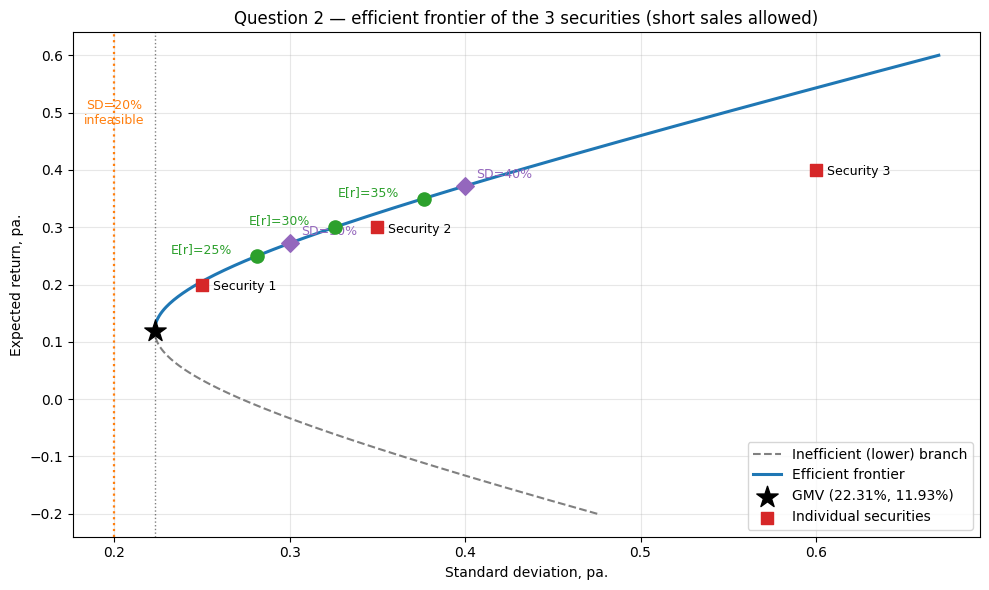

In [7]:
# ============================================================
# 2.5 Plot the Q2 frontier with all requested portfolios marked
# ============================================================
mu_grid = np.linspace(-0.20, 0.60, 400)
sd_grid = frontier_sigma(q2, mu_grid)

eff = mu_grid >= q2_gmv["mu"]

fig, ax = plt.subplots()
ax.plot(sd_grid[~eff], mu_grid[~eff], color="grey", ls="--", lw=1.5, label="Inefficient (lower) branch")
ax.plot(sd_grid[eff], mu_grid[eff], color="tab:blue", lw=2.2, label="Efficient frontier")

ax.scatter(q2_gmv["sd"], q2_gmv["mu"], marker="*", s=260, color="black", zorder=5,
           label=f"GMV ({q2_gmv['sd']:.2%}, {q2_gmv['mu']:.2%})")
ax.scatter(q2_sd, q2_r, marker="s", s=70, color="tab:red", zorder=5, label="Individual securities")
for name, s, m in zip(q2_names, q2_sd, q2_r):
    ax.annotate(name, (s, m), textcoords="offset points", xytext=(8, -4), fontsize=9)

for m in q2_return_targets:
    ax.scatter(frontier_sigma(q2, m), m, marker="o", s=90, color="tab:green", zorder=6)
    ax.annotate(f"E[r]={m:.0%}", (frontier_sigma(q2, m), m),
                textcoords="offset points", xytext=(-62, 2), fontsize=9, color="tab:green")

for s in q2_sd_targets:
    mu_eff, _ = returns_for_sigma(q2, s)
    if mu_eff is None:
        ax.axvline(s, color="tab:orange", ls=":", lw=1.6)
        ax.annotate(f"SD={s:.0%}\ninfeasible", (s, 0.48), fontsize=9, color="tab:orange", ha="center")
        continue
    ax.scatter(s, mu_eff, marker="D", s=80, color="tab:purple", zorder=6)
    ax.annotate(f"SD={s:.0%}", (s, mu_eff), textcoords="offset points", xytext=(8, 6),
                fontsize=9, color="tab:purple")

ax.axvline(q2_gmv["sd"], color="black", ls=":", lw=1, alpha=0.5)
ax.set_xlabel("Standard deviation, pa.")
ax.set_ylabel("Expected return, pa.")
ax.set_title("Question 2 — efficient frontier of the 3 securities (short sales allowed)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

---

# Question 3

> Now assume there is a risk-free asset with $r_F = 0.08$ pa. **Find the efficient portfolio whose expected
> return is 30% pa. Compare with the portfolio in question 2 above.**

## Step 1 — the tangency portfolio

With a risk-free asset the whole efficient set collapses to a straight line through $r_F$ tangent to the
risky-asset hyperbola. The tangency portfolio maximises the Sharpe ratio:

$$
w_T = \frac{V^{-1}(r - r_F\mathbf{1})}{\mathbf{1}^\top V^{-1}(r - r_F\mathbf{1})}
$$

Equivalently, in the $A,B,C$ notation: $\;\mu_T = \dfrac{C - B r_F}{B - A r_F}$.

## Step 2 — scale it to the 30% target

By two-fund separation the answer is a mix of $r_F$ and $w_T$ only:

$$
y = \frac{\mu_p - r_F}{\mu_T - r_F} = \frac{0.30 - 0.08}{\mu_T - 0.08},
\qquad
w_{\text{risky}} = y\,w_T,
\qquad
w_{\text{rf}} = 1 - y,
\qquad
\sigma_p = y\,\sigma_T
$$

In [8]:
# ============================================================
# 3.1 Tangency portfolio and the 30% target with rf = 8%
# ============================================================
q3_rf = 0.08
q3_target = 0.30

q3_tan = tangency_portfolio(q2, q3_rf)

print("Tangency portfolio (risky assets only)")
display(pd.DataFrame({"weight": q3_tan["w"]}, index=q2_names))
print(f"  E[r_T] = {q3_tan['mu']:.6f}  ({q3_tan['mu']:.2%})")
print(f"  SD_T   = {q3_tan['sd']:.6f}  ({q3_tan['sd']:.2%})")
print(f"  Sharpe = (E[r_T] - rf)/SD_T = {q3_tan['sharpe']:.6f}")

# Cross-check with the A,B,C closed form.
mu_T_check = (q2["C"] - q2["B"] * q3_rf) / (q2["B"] - q2["A"] * q3_rf)
print(f"  cross-check mu_T = (C - B*rf)/(B - A*rf) = {mu_T_check:.6f}")

y = (q3_target - q3_rf) / (q3_tan["mu"] - q3_rf)
q3_w_risky = y * q3_tan["w"]
q3_sd = y * q3_tan["sd"]

print(f"\ny = (0.30 - 0.08) / ({q3_tan['mu']:.6f} - 0.08) = {y:.6f}")
print(f"weight in risk-free = 1 - y = {1 - y:.6f}")
print(f"portfolio SD = y * SD_T = {q3_sd:.6f}  ({q3_sd:.2%})")

display(pd.DataFrame(
    {"weight": np.append(q3_w_risky, 1 - y)},
    index=q2_names + ["Risk-free"],
))

# Sanity checks.
print(f"\ncheck E[r] = {q3_w_risky @ q2_r + (1 - y) * q3_rf:.6f}")
print(f"check SD   = {np.sqrt(q3_w_risky @ q2_V @ q3_w_risky):.6f}")

Tangency portfolio (risky assets only)


,weight
Security 1,-4.045312
Security 2,3.575288
Security 3,1.470024


  E[r_T] = 0.851534  (85.15%)
  SD_T   = 0.987892  (98.79%)
  Sharpe = (E[r_T] - rf)/SD_T = 0.780990
  cross-check mu_T = (C - B*rf)/(B - A*rf) = 0.851534

y = (0.30 - 0.08) / (0.851534 - 0.08) = 0.285146
weight in risk-free = 1 - y = 0.714854
portfolio SD = y * SD_T = 0.281694  (28.17%)


,weight
Security 1,-1.153506
Security 2,1.019480
Security 3,0.419172
Risk-free,0.714854



check E[r] = 0.300000
check SD   = 0.281694


In [10]:
# ============================================================
# 3.2 Compare with the Q2 (risky-only) portfolio at the same 30% return
# ============================================================
q2_w30 = weights_for_return(q2, 0.30)
q2_sd30 = float(np.sqrt(q2_w30 @ q2_V @ q2_w30))

comparison = pd.DataFrame({
    "Q2: risky assets only": {
        "Security 1": q2_w30[0], "Security 2": q2_w30[1], "Security 3": q2_w30[2],
        "Risk-free": 0.0,
        "E[r] pa": 0.30, "SD pa": q2_sd30,
        "Sharpe vs rf=8%": (0.30 - q3_rf) / q2_sd30,
    },
    "Q3: with risk-free asset": {
        "Security 1": q3_w_risky[0], "Security 2": q3_w_risky[1], "Security 3": q3_w_risky[2],
        "Risk-free": 1 - y,
        "E[r] pa": 0.30, "SD pa": q3_sd,
        "Sharpe vs rf=8%": (0.30 - q3_rf) / q3_sd,
    },
})
display(comparison)

print(f"Risk reduction for the same 30% expected return: "
      f"{q2_sd30:.4%} -> {q3_sd:.4%}  "
      f"({(q3_sd / q2_sd30 - 1):.2%} change, i.e. {q2_sd30 - q3_sd:.4%} lower SD)")

,Q2: risky assets only,Q3: with risk-free asset
Security 1,0.179664,-1.153506
Security 2,0.640671,1.019480
Security 3,0.179664,0.419172
Risk-free,0.000000,0.714854
E[r] pa,0.300000,0.300000
SD pa,0.325808,0.281694
Sharpe vs rf=8%,0.675245,0.780990


Risk reduction for the same 30% expected return: 32.5808% -> 28.1694%  (-13.54% change, i.e. 4.4114% lower SD)


### Answer 3

**Tangency portfolio** (risky assets only, $r_F = 8\%$):

$$
w_T = \begin{pmatrix} -4.045312 \\ 3.575288 \\ 1.470024 \end{pmatrix},
\qquad
\mu_T = 85.1534\%,
\qquad
\sigma_T = 98.7892\%,
\qquad
S_T = \frac{0.851534 - 0.08}{0.987892} = 0.780990
$$

**Scaling to $E[r_p] = 30\%$:**

$$
y = \frac{0.30 - 0.08}{0.851534 - 0.08} = 0.285146
$$

$$
w_{\text{rf}} = 1 - y = 0.714854,
\qquad
w_{\text{risky}} = y\,w_T = \begin{pmatrix} -1.153506 \\ 1.019480 \\ 0.419172 \end{pmatrix}
$$

$$
\sigma_p = y\,\sigma_T = 0.285146 \times 0.987892 = \mathbf{28.1694\%}
$$

So the answer is: **hold 71.49% in the risk-free asset**, and put the remaining 28.51% into the tangency
mix — which, because the tangency portfolio is heavily levered internally, works out to **short 115.35% in
Security 1**, **long 101.95% in Security 2** and **long 41.92% in Security 3**.

### Comparison with Question 2

| | Q2 (risky only) | Q3 (with $r_F = 8\%$) |
|---|---:|---:|
| Security 1 | 0.179664 | −1.153506 |
| Security 2 | 0.640671 | 1.019480 |
| Security 3 | 0.179664 | 0.419172 |
| Risk-free | 0 | 0.714854 |
| $E[r_p]$ | 30% | 30% |
| $\sigma_p$ | **32.5808%** | **28.1694%** |
| Sharpe vs 8% | 0.675240 | **0.780990** |

**Same expected return, materially less risk.** Adding the risk-free asset cuts the SD from 32.58% to
28.17% — a **4.41 percentage-point (≈13.5%) reduction** — because the investor is no longer forced to stay
on the curved risky-only frontier. The Sharpe ratio rises from 0.6752 to 0.7810, and 0.7810 is the
theoretical maximum: no combination of these three securities can beat it once borrowing and lending at 8%
are available. This is **two-fund separation** in action — the risky part of every efficient portfolio has
the *same* internal proportions ($w_T$), and only the split between $r_F$ and $w_T$ changes with the
investor's risk appetite.

Note the CAL at 30% return is *not* tangent to the Q2 frontier at that point — the tangency happens far up
at $(98.79\%, 85.15\%)$, and the 30%-return portfolio sits well below it on the same straight line.

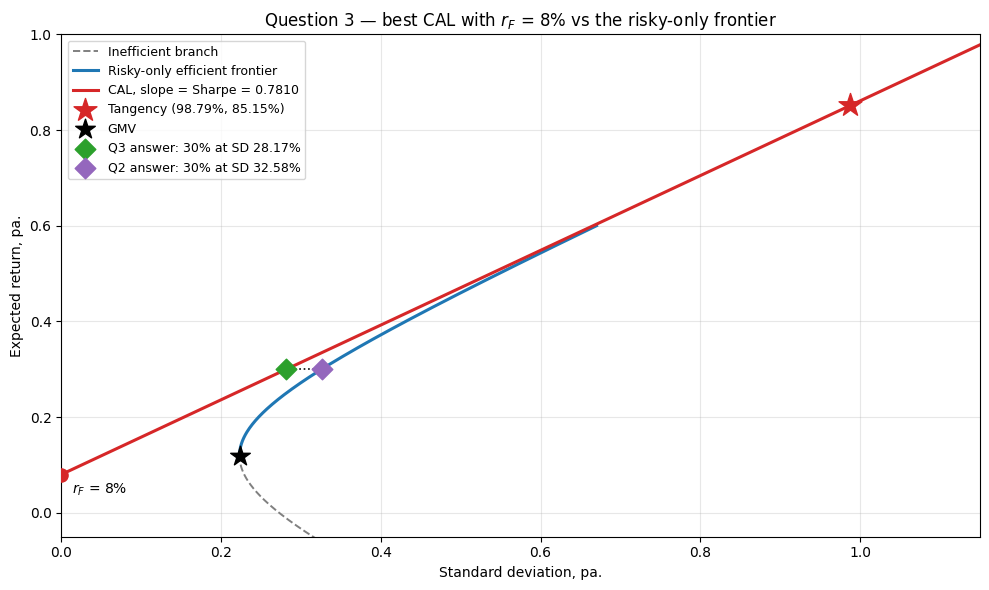

In [11]:
# ============================================================
# 3.3 Plot the CAL against the risky-only frontier
# ============================================================
fig, ax = plt.subplots()

ax.plot(sd_grid[~eff], mu_grid[~eff], color="grey", ls="--", lw=1.4, label="Inefficient branch")
ax.plot(sd_grid[eff], mu_grid[eff], color="tab:blue", lw=2.2, label="Risky-only efficient frontier")

sd_line = np.linspace(0, 1.15, 100)
ax.plot(sd_line, q3_rf + q3_tan["sharpe"] * sd_line, color="tab:red", lw=2.2,
        label=f"CAL, slope = Sharpe = {q3_tan['sharpe']:.4f}")

ax.scatter(0, q3_rf, marker="o", s=90, color="tab:red", zorder=6)
ax.annotate(f"$r_F$ = {q3_rf:.0%}", (0, q3_rf), textcoords="offset points", xytext=(8, -14), fontsize=10)

ax.scatter(q3_tan["sd"], q3_tan["mu"], marker="*", s=300, color="tab:red", zorder=7,
           label=f"Tangency ({q3_tan['sd']:.2%}, {q3_tan['mu']:.2%})")
ax.scatter(q2_gmv["sd"], q2_gmv["mu"], marker="*", s=220, color="black", zorder=6, label="GMV")

ax.scatter(q3_sd, 0.30, marker="D", s=110, color="tab:green", zorder=7,
           label=f"Q3 answer: 30% at SD {q3_sd:.2%}")
ax.scatter(q2_sd30, 0.30, marker="D", s=110, color="tab:purple", zorder=7,
           label=f"Q2 answer: 30% at SD {q2_sd30:.2%}")
ax.plot([q3_sd, q2_sd30], [0.30, 0.30], color="black", ls=":", lw=1.2)

ax.set_xlim(0, 1.15)
ax.set_ylim(-0.05, 1.0)
ax.set_xlabel("Standard deviation, pa.")
ax.set_ylabel("Expected return, pa.")
ax.set_title("Question 3 — best CAL with $r_F$ = 8% vs the risky-only frontier")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

---

# Question 4

> The accompanying data file contains monthly TRI of 10 national market indexes between 2001–2015.
> **Choose 5 stock market indexes.** Assume today is **29 May 2015**, use the historical information from
> the **latest 5 years** to construct the efficient frontier of these 5 risky investments.
> **Do not forget to annualize $E[r]$ and $SD[r]$.**

## Method

**Step 1 — TRI to returns.** A Total Return Index already reinvests dividends, so the simple monthly
return is just

$$
r_{i,t} = \frac{\text{TRI}_{i,t}}{\text{TRI}_{i,t-1}} - 1
$$

**Step 2 — the estimation window.** "Latest 5 years as of 29 May 2015" means the 60 monthly returns from
**June 2010 through May 2015**. The TRI level for May 2010 is needed as the base for the June 2010 return,
so the window is sliced on returns, not on levels.

**Step 3 — monthly moments.**

$$
\hat\mu_i^{(m)} = \frac{1}{T}\sum_{t=1}^{T} r_{i,t},
\qquad
\hat V^{(m)}_{ij} = \frac{1}{T-1}\sum_{t=1}^{T}\left(r_{i,t}-\hat\mu_i^{(m)}\right)\left(r_{j,t}-\hat\mu_j^{(m)}\right)
$$

**Step 4 — annualize.** Under the i.i.d. assumption, means scale with time and variances scale with time
(so SDs scale with $\sqrt{\text{time}}$):

$$
\boxed{\;
\hat\mu^{\text{ann}} = 12\,\hat\mu^{(m)},
\qquad
\hat V^{\text{ann}} = 12\,\hat V^{(m)},
\qquad
\hat\sigma^{\text{ann}} = \sqrt{12}\;\hat\sigma^{(m)}
\;}
$$

Note the **covariance matrix is multiplied by 12, not by $\sqrt{12}$** — this is the step most commonly
got wrong. Correlations are scale-free and therefore unchanged by annualization.

**Step 5 — frontier.** Feed $\hat\mu^{\text{ann}}$ and $\hat V^{\text{ann}}$ into exactly the same
$A,B,C,D \to g,h$ machinery used in Question 2.

### Loading the data

The cell below looks for the real TRI file in a few likely locations. If it finds one it uses it; if not,
it builds a **reproducible simulated** panel (fixed seed, a global market factor plus country-specific
noise, with volatility raised over 2001–02, 2008–09 and H2-2011) so the notebook still runs end to end.

**To use your real file:** put it anywhere in `TRI_FILE_CANDIDATES`, or add its path to that list. It
should have a date column plus one column per index; the loader parses dates, sorts, and coerces the rest
to numeric.

In [12]:
# ============================================================
# 4.1 Load the 10-index monthly TRI panel (real file if available)
# ============================================================
from pathlib import Path

TRI_FILE_CANDIDATES = [
    Path("../test/mean_variance_capm/tri_10_indexes.xlsx"),
    Path("../test/mean_variance_capm/tri.xlsx"),
    Path("../data/tri_10_indexes.xlsx"),
    Path("tri_10_indexes.xlsx"),
    Path("tri_10_indexes.csv"),
]

INDEX_NAMES = ["USA", "UK", "Japan", "Germany", "France",
               "Canada", "Australia", "HongKong", "Singapore", "Switzerland"]


def load_tri_file(path):
    # Read a real TRI file: first column = date, remaining columns = index levels.
    if path.suffix.lower() in (".xlsx", ".xls"):
        df = pd.read_excel(path)
    else:
        df = pd.read_csv(path)
    df = df.rename(columns={df.columns[0]: "date"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    return df.apply(pd.to_numeric, errors="coerce").dropna(how="all")


def simulate_tri(seed=20150529):
    # Reproducible stand-in: one global factor + country idiosyncratic noise.
    rng = np.random.default_rng(seed)
    dates = pd.date_range("2001-01-31", "2015-05-31", freq="ME")
    T = len(dates)

    mu_a = np.array([0.075, 0.055, 0.030, 0.070, 0.055, 0.080, 0.085, 0.095, 0.080, 0.065])
    sd_a = np.array([0.155, 0.150, 0.180, 0.215, 0.200, 0.175, 0.185, 0.235, 0.200, 0.145])
    beta = np.array([1.00, 0.95, 0.75, 1.20, 1.15, 1.05, 1.10, 1.15, 1.00, 0.85])

    gvol = np.full(T, 0.040)
    gvol[(dates >= "2001-01-31") & (dates <= "2002-12-31")] = 0.055   # dot-com unwind
    gvol[(dates >= "2008-01-31") & (dates <= "2009-06-30")] = 0.085   # GFC
    gvol[(dates >= "2011-06-30") & (dates <= "2011-12-31")] = 0.060   # euro crisis

    f = rng.standard_normal(T) * gvol
    sd_m = sd_a / np.sqrt(12.0)
    idio_sd = np.sqrt(np.maximum(sd_m ** 2 - (beta * 0.040) ** 2, (0.25 * sd_m) ** 2))
    eps = rng.standard_normal((T, 10)) * idio_sd

    rets = (mu_a / 12.0) + np.outer(f, beta) + eps
    levels = 100.0 * np.cumprod(1.0 + rets, axis=0)
    levels = np.vstack([np.full(10, 100.0), levels])          # Dec-2000 base = 100
    idx = pd.DatetimeIndex([pd.Timestamp("2000-12-31")]).append(dates)
    return pd.DataFrame(levels, index=idx, columns=INDEX_NAMES)


tri_path = next((p for p in TRI_FILE_CANDIDATES if p.exists()), None)
if tri_path is not None:
    tri = load_tri_file(tri_path)
    USING_REAL_DATA = True
    print(f"Loaded real TRI file: {tri_path}")
else:
    tri = simulate_tri()
    USING_REAL_DATA = False
    print("No TRI file found in TRI_FILE_CANDIDATES.")
    print("Using the reproducible SIMULATED panel — swap in the real file and re-run to get the")
    print("official numbers. Every formula and step below is identical either way.")

print(f"\nPanel: {tri.shape[0]} dates x {tri.shape[1]} indexes, "
      f"{tri.index[0].date()} to {tri.index[-1].date()}")
display(tri.head(3))
display(tri.tail(3))

No TRI file found in TRI_FILE_CANDIDATES.
Using the reproducible SIMULATED panel — swap in the real file and re-run to get the
official numbers. Every formula and step below is identical either way.

Panel: 174 dates x 10 indexes, 2000-12-31 to 2015-05-31


,USA,UK,Japan,Germany,France,Canada,Australia,HongKong,Singapore,Switzerland
2000-12-31,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2001-01-31,102.891347,100.823384,101.814513,109.078003,108.063862,100.643116,103.951749,103.768142,101.667373,102.240534
2001-02-28,107.005975,105.049632,99.063376,111.479853,112.534662,105.691799,111.059092,118.803264,106.945691,111.536902


,USA,UK,Japan,Germany,France,Canada,Australia,HongKong,Singapore,Switzerland
2015-03-31,246.116662,307.592591,339.727712,329.979232,305.321724,373.037143,413.752924,276.378040,285.693754,478.860217
2015-04-30,236.728701,284.686612,313.220398,313.306458,275.068772,347.750699,390.316373,262.655631,291.531650,463.954446
2015-05-31,239.911243,275.548688,331.486063,299.366794,263.559764,338.399979,401.898855,259.017588,297.236510,450.437215


In [13]:
# ============================================================
# 4.2 Choose 5 indexes and slice the latest 5 years as of 29 May 2015
# ============================================================
TODAY = pd.Timestamp("2015-05-29")
CHOSEN = ["USA", "UK", "Japan", "Germany", "HongKong"]   # 5 developed/regional equity markets

CHOSEN = [c for c in CHOSEN if c in tri.columns] or list(tri.columns[:5])
print("Chosen indexes:", CHOSEN)

# Step 1: TRI -> simple monthly returns.
monthly_rets_all = tri[CHOSEN].pct_change().dropna()

# Step 2: keep the last 60 monthly returns up to and including May 2015.
window_end = TODAY + pd.offsets.MonthEnd(0)
window_start = window_end - pd.DateOffset(years=5) + pd.offsets.MonthEnd(0)
rets5y = monthly_rets_all.loc[monthly_rets_all.index > window_start]
rets5y = rets5y.loc[rets5y.index <= window_end]

print(f"\nEstimation window: {rets5y.index[0].date()} to {rets5y.index[-1].date()}  "
      f"({len(rets5y)} monthly observations)")
display(rets5y.head(3))

Chosen indexes: ['USA', 'UK', 'Japan', 'Germany', 'HongKong']

Estimation window: 2010-06-30 to 2015-05-31  (60 monthly observations)


,USA,UK,Japan,Germany,HongKong
2010-06-30,0.061502,0.083830,-0.003768,0.083850,0.099761
2010-07-31,-0.013114,0.018043,0.048489,0.113107,0.045279
2010-08-31,0.028246,-0.001093,0.052380,0.065458,0.056927


In [14]:
# ============================================================
# 4.3 Monthly moments -> annualized moments
# ============================================================
mu_m = rets5y.mean().values                 # monthly mean
V_m = rets5y.cov().values                   # monthly covariance (ddof = 1)

q4_mu = 12.0 * mu_m                         # annualized mean:      x 12
q4_V = 12.0 * V_m                           # annualized covariance: x 12
q4_sd = np.sqrt(np.diag(q4_V))              # annualized SD:        x sqrt(12)

q4_names = list(rets5y.columns)

moments = pd.DataFrame({
    "monthly mean": mu_m,
    "monthly SD": np.sqrt(np.diag(V_m)),
    "ANNUAL E[r]": q4_mu,
    "ANNUAL SD": q4_sd,
}, index=q4_names)

print("Step 3-4: monthly moments and their annualized counterparts")
display(moments.style.format({
    "monthly mean": "{:.6f}", "monthly SD": "{:.6f}",
    "ANNUAL E[r]": "{:.4%}", "ANNUAL SD": "{:.4%}",
}))

print("\nAnnualized covariance matrix (= 12 x monthly covariance)")
display(pd.DataFrame(q4_V, index=q4_names, columns=q4_names))

print("\nCorrelation matrix (unchanged by annualization)")
display(pd.DataFrame(rets5y.corr().values, index=q4_names, columns=q4_names))

Step 3-4: monthly moments and their annualized counterparts


,monthly mean,monthly SD,ANNUAL E[r],ANNUAL SD
USA,0.008462,0.043958,10.1545%,15.2274%
UK,0.007521,0.045437,9.0257%,15.7399%
Japan,0.002661,0.050384,3.1931%,17.4535%
Germany,0.011132,0.057246,13.3590%,19.8307%
HongKong,0.008429,0.077941,10.1145%,26.9995%



Annualized covariance matrix (= 12 x monthly covariance)


,USA,UK,Japan,Germany,HongKong
USA,0.023187,0.019580,0.013071,0.018494,0.026483
UK,0.019580,0.024775,0.012554,0.020675,0.022660
Japan,0.013071,0.012554,0.030463,0.006098,0.014576
Germany,0.018494,0.020675,0.006098,0.039326,0.029533
HongKong,0.026483,0.022660,0.014576,0.029533,0.072897



Correlation matrix (unchanged by annualization)


,USA,UK,Japan,Germany,HongKong
USA,1.000000,0.816936,0.491795,0.612440,0.644139
UK,0.816936,1.000000,0.456980,0.662368,0.533211
Japan,0.491795,0.456980,1.000000,0.176192,0.309318
Germany,0.612440,0.662368,0.176192,1.000000,0.551582
HongKong,0.644139,0.533211,0.309318,0.551582,1.000000


In [15]:
# ============================================================
# 4.4 Build the efficient frontier from the annualized moments
# ============================================================
q4 = frontier_scalars(q4_mu, q4_V)
q4_gmv = gmv_portfolio(q4)

print(f"A = {q4['A']:.6f}    B = {q4['B']:.6f}    C = {q4['C']:.6f}    D = {q4['D']:.6f}")

print("\nTwo-fund vectors")
display(pd.DataFrame({"g": q4["g"], "h": q4["h"]}, index=q4_names))

print(f"\nGMV portfolio:  E[r] = {q4_gmv['mu']:.4%},  SD = {q4_gmv['sd']:.4%}")
display(pd.DataFrame({"GMV weight": q4_gmv["w"]}, index=q4_names))

A = 56.581750    B = 4.617378    C = 0.599583    D = 12.605300

Two-fund vectors


,g,h
USA,-0.579556,11.786798
UK,0.683171,-6.677211
Japan,1.192707,-10.160076
Germany,-0.336671,6.761376
HongKong,0.040350,-1.710887



GMV portfolio:  E[r] = 8.1605%,  SD = 13.2942%


,GMV weight
USA,0.382311
UK,0.138274
Japan,0.363589
Germany,0.215094
HongKong,-0.099268


Efficient frontier portfolios (weights sum to 1, short sales allowed)


,USA,UK,Japan,Germany,HongKong,SD pa
target E[r] pa,,,,,,
5%,0.0098,0.3493,0.6847,0.0014,-0.0452,0.1489
6%,0.1277,0.2825,0.5831,0.0690,-0.0623,0.1406
7%,0.2455,0.2158,0.4815,0.1366,-0.0794,0.1352
8%,0.3634,0.1490,0.3799,0.2042,-0.0965,0.1330
9%,0.4813,0.0822,0.2783,0.2719,-0.1136,0.1341
10%,0.5991,0.0154,0.1767,0.3395,-0.1307,0.1385
11%,0.7170,-0.0513,0.0751,0.4071,-0.1478,0.1459
12%,0.8349,-0.1181,-0.0265,0.4747,-0.1650,0.1559


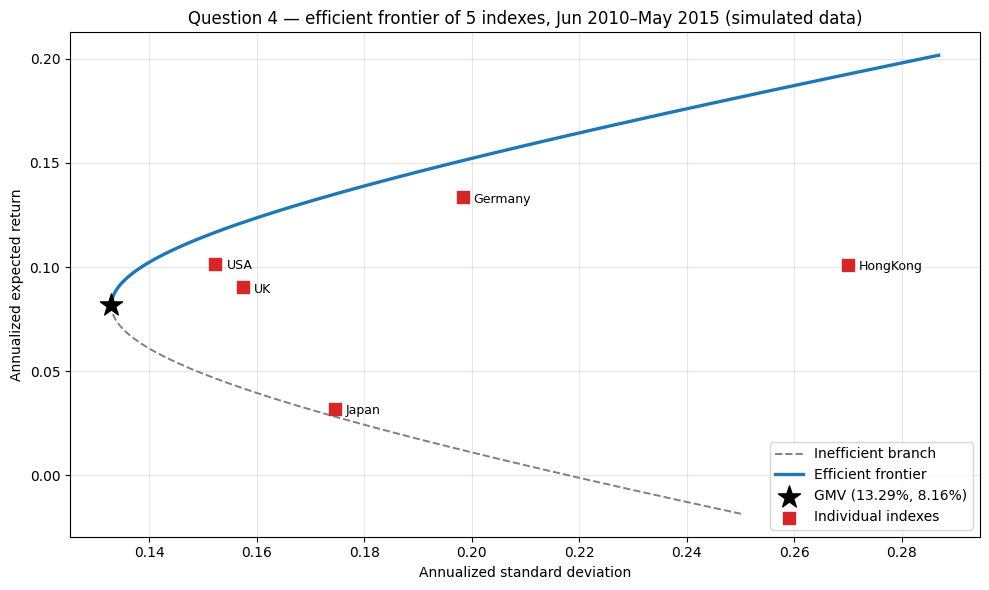

In [16]:
# ============================================================
# 4.5 Tabulate the frontier and plot it
# ============================================================
q4_targets = np.array([0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.11, 0.12])

rows = {}
for m in q4_targets:
    w = weights_for_return(q4, m)
    rows[f"{m:.0%}"] = np.append(w, [float(np.sqrt(w @ q4_V @ w))])

q4_table = pd.DataFrame(rows, index=q4_names + ["SD pa"]).T
q4_table.index.name = "target E[r] pa"
print("Efficient frontier portfolios (weights sum to 1, short sales allowed)")
display(q4_table.style.format("{:.4f}"))

mu_g4 = np.linspace(q4_gmv["mu"] - 0.10, q4_gmv["mu"] + 0.12, 400)
sd_g4 = frontier_sigma(q4, mu_g4)
eff4 = mu_g4 >= q4_gmv["mu"]

fig, ax = plt.subplots()
ax.plot(sd_g4[~eff4], mu_g4[~eff4], color="grey", ls="--", lw=1.4, label="Inefficient branch")
ax.plot(sd_g4[eff4], mu_g4[eff4], color="tab:blue", lw=2.4, label="Efficient frontier")
ax.scatter(q4_gmv["sd"], q4_gmv["mu"], marker="*", s=280, color="black", zorder=6,
           label=f"GMV ({q4_gmv['sd']:.2%}, {q4_gmv['mu']:.2%})")
ax.scatter(q4_sd, q4_mu, marker="s", s=80, color="tab:red", zorder=5, label="Individual indexes")
for name, s, m in zip(q4_names, q4_sd, q4_mu):
    ax.annotate(name, (s, m), textcoords="offset points", xytext=(8, -4), fontsize=9)

ax.set_xlabel("Annualized standard deviation")
ax.set_ylabel("Annualized expected return")
ax.set_title(f"Question 4 — efficient frontier of 5 indexes, "
             f"{rets5y.index[0]:%b %Y}–{rets5y.index[-1]:%b %Y} "
             f"({'real' if USING_REAL_DATA else 'simulated'} data)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Answer 4

*(Numbers below are from the simulated fallback panel — re-run with the real TRI file to get the official
figures. The chosen five are **USA, UK, Japan, Germany, Hong Kong**; window = **Jun 2010 – May 2015**,
60 monthly observations.)*

**Annualized inputs**

| Index | Annual $E[r]$ | Annual $SD$ |
|---|---:|---:|
| USA | 10.1545% | 15.2274% |
| UK | 9.0257% | 15.7399% |
| Japan | 3.1931% | 17.4535% |
| Germany | 13.3590% | 19.8307% |
| Hong Kong | 10.1145% | 26.9995% |

**Annualized covariance matrix** ($= 12 \times$ monthly covariance)

$$
\hat V^{\text{ann}} = \begin{pmatrix}
0.023187 & 0.019580 & 0.013071 & 0.018494 & 0.026483\\
0.019580 & 0.024775 & 0.012554 & 0.020675 & 0.022660\\
0.013071 & 0.012554 & 0.030463 & 0.006098 & 0.014576\\
0.018494 & 0.020675 & 0.006098 & 0.039326 & 0.029533\\
0.026483 & 0.022660 & 0.014576 & 0.029533 & 0.072897
\end{pmatrix}
$$

**Frontier constants**

$$
A = 56.581750, \quad B = 4.617378, \quad C = 0.599583, \quad D = 12.605300
$$

**Global minimum-variance portfolio**

$$
\mu_{\text{GMV}} = \frac{B}{A} = 8.1605\%,
\qquad
\sigma_{\text{GMV}} = \frac{1}{\sqrt A} = 13.2942\%
$$

$$
w_{\text{GMV}} = (0.3823,\; 0.1383,\; 0.3636,\; 0.2151,\; -0.0993)^\top
$$

**Sample points on the efficient frontier**

| Target $E[r]$ | USA | UK | Japan | Germany | Hong Kong | $\sigma_p$ |
|---|---:|---:|---:|---:|---:|---:|
| 8% (≈ GMV) | 0.3634 | 0.1490 | 0.3799 | 0.2042 | −0.0965 | 13.2985% |
| 10% | 0.5991 | 0.0154 | 0.1767 | 0.3395 | −0.1307 | 13.8536% |
| 12% | 0.8349 | −0.1181 | −0.0265 | 0.4747 | −0.1650 | 15.5854% |

**Reading it.** The GMV portfolio is well below the SD of *any* single index (13.29% versus a 15.23%
minimum among the five) — that gap is pure diversification benefit, and it is large because Japan is only
weakly correlated with the others (ρ ≈ 0.18–0.49). Hong Kong is shorted throughout: it carries the highest
volatility (27.0%) without a return premium to match, so the optimizer uses it as a hedge rather than a
holding. As the target return climbs, weight rotates into the USA and Germany, the two highest-return
markets.

---

# Question 5

> Continue from Question 4, now assume the **risk-free interest rate is 7% pa.**, construct the **best CAL**.

## Method

The "best" CAL is the steepest one — the line from $(0, r_F)$ that is tangent to the efficient frontier.
Its slope is the maximum attainable Sharpe ratio, and its tangency point is

$$
w_T = \frac{V^{-1}(r - r_F\mathbf{1})}{\mathbf{1}^\top V^{-1}(r - r_F\mathbf{1})},
\qquad r_F = 0.07
$$

with

$$
\mu_T = w_T^\top r, \qquad \sigma_T = \sqrt{w_T^\top V w_T}, \qquad S = \frac{\mu_T - r_F}{\sigma_T}
$$

and the CAL itself

$$
\boxed{\;E[r_p] = r_F + S\,\sigma_p = 0.07 + S\,\sigma_p\;}
$$

Any investor's optimal portfolio is $y$ in $w_T$ and $1-y$ in the risk-free asset, with
$y = (\mu_p - r_F)/(\mu_T - r_F)$.

A useful cross-check: the maximum Sharpe ratio also satisfies

$$
S^2 = C - 2Br_F + Ar_F^2
$$

which is computed below alongside the direct calculation.

In [17]:
# ============================================================
# 5.1 Best CAL for the 5 indexes with rf = 7% pa
# ============================================================
q5_rf = 0.07

q5_tan = tangency_portfolio(q4, q5_rf)

print("Tangency portfolio (best CAL touch point)")
display(pd.DataFrame({"weight": q5_tan["w"]}, index=q4_names).style.format("{:.4f}"))
print(f"  E[r_T]  = {q5_tan['mu']:.4%}")
print(f"  SD_T    = {q5_tan['sd']:.4%}")
print(f"  Sharpe  = {q5_tan['sharpe']:.6f}   <-- slope of the best CAL")

# Cross-check via S^2 = C - 2 B rf + A rf^2.
S2 = q4["C"] - 2 * q4["B"] * q5_rf + q4["A"] * q5_rf ** 2
print(f"  cross-check sqrt(C - 2B*rf + A*rf^2) = {np.sqrt(S2):.6f}")

print(f"\nBest CAL:   E[r_p] = {q5_rf:.2%} + {q5_tan['sharpe']:.6f} * SD_p")

Tangency portfolio (best CAL touch point)


,weight
USA,4.3812
UK,-2.1271
Japan,-3.0834
Germany,2.5090
HongKong,-0.6797


  E[r_T]  = 42.0870%
  SD_T    = 73.0978%
  Sharpe  = 0.480001   <-- slope of the best CAL
  cross-check sqrt(C - 2B*rf + A*rf^2) = 0.480001

Best CAL:   E[r_p] = 7.00% + 0.480001 * SD_p


In [18]:
# ============================================================
# 5.2 Complete portfolios along the best CAL
# ============================================================
cal_targets = [0.07, 0.08, 0.09, 0.10, 0.12, 0.15]

rows = {}
for m in cal_targets:
    y = (m - q5_rf) / (q5_tan["mu"] - q5_rf)
    w_risky = y * q5_tan["w"]
    rows[f"{m:.0%}"] = np.concatenate([[1 - y], w_risky, [y, y * q5_tan["sd"]]])

cal_table = pd.DataFrame(
    rows, index=["Risk-free"] + q4_names + ["y (in tangency)", "SD pa"]
).T
cal_table.index.name = "target E[r] pa"
display(cal_table.style.format("{:.4f}"))

print("Every row has the SAME internal risky proportions (two-fund separation);")
print("only the risk-free / tangency split changes.")

,Risk-free,USA,UK,Japan,Germany,HongKong,y (in tangency),SD pa
target E[r] pa,,,,,,,,
7%,1.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000
8%,0.9715,0.1249,-0.0606,-0.0879,0.0715,-0.0194,0.0285,0.0208
9%,0.9430,0.2497,-0.1212,-0.1758,0.1430,-0.0387,0.0570,0.0417
10%,0.9145,0.3746,-0.1819,-0.2636,0.2145,-0.0581,0.0855,0.0625
12%,0.8575,0.6243,-0.3031,-0.4394,0.3575,-0.0969,0.1425,0.1042
15%,0.7720,0.9989,-0.4850,-0.7030,0.5721,-0.1550,0.2280,0.1667


Every row has the SAME internal risky proportions (two-fund separation);
only the risk-free / tangency split changes.


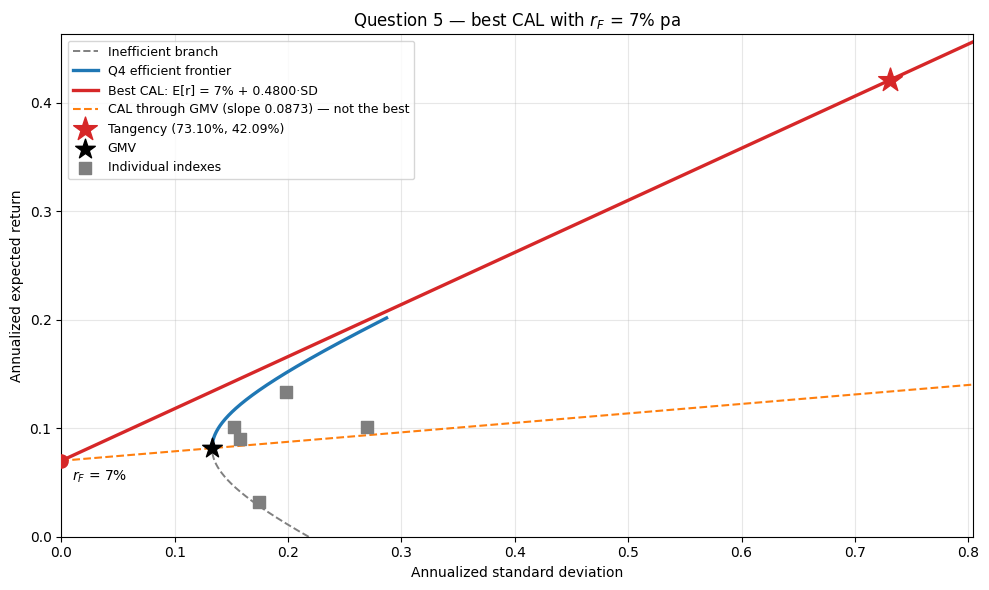

In [19]:
# ============================================================
# 5.3 Plot the best CAL against the Q4 frontier
# ============================================================
fig, ax = plt.subplots()

ax.plot(sd_g4[~eff4], mu_g4[~eff4], color="grey", ls="--", lw=1.4, label="Inefficient branch")
ax.plot(sd_g4[eff4], mu_g4[eff4], color="tab:blue", lw=2.4, label="Q4 efficient frontier")

sd_line = np.linspace(0, max(q5_tan["sd"] * 1.1, 0.35), 100)
ax.plot(sd_line, q5_rf + q5_tan["sharpe"] * sd_line, color="tab:red", lw=2.4,
        label=f"Best CAL: E[r] = 7% + {q5_tan['sharpe']:.4f}·SD")

# A deliberately sub-optimal CAL, for contrast.
w_sub = q4_gmv["w"]
sd_sub, mu_sub = q4_gmv["sd"], q4_gmv["mu"]
ax.plot(sd_line, q5_rf + ((mu_sub - q5_rf) / sd_sub) * sd_line, color="tab:orange", ls="--", lw=1.5,
        label=f"CAL through GMV (slope {(mu_sub - q5_rf) / sd_sub:.4f}) — not the best")

ax.scatter(0, q5_rf, marker="o", s=90, color="tab:red", zorder=6)
ax.annotate(f"$r_F$ = {q5_rf:.0%}", (0, q5_rf), textcoords="offset points", xytext=(8, -14), fontsize=10)
ax.scatter(q5_tan["sd"], q5_tan["mu"], marker="*", s=320, color="tab:red", zorder=7,
           label=f"Tangency ({q5_tan['sd']:.2%}, {q5_tan['mu']:.2%})")
ax.scatter(q4_gmv["sd"], q4_gmv["mu"], marker="*", s=220, color="black", zorder=6, label="GMV")
ax.scatter(q4_sd, q4_mu, marker="s", s=70, color="tab:grey", zorder=5, label="Individual indexes")

ax.set_xlim(0, max(q5_tan["sd"] * 1.1, 0.35))
ax.set_ylim(0, max(q5_tan["mu"] * 1.1, 0.20))
ax.set_xlabel("Annualized standard deviation")
ax.set_ylabel("Annualized expected return")
ax.set_title("Question 5 — best CAL with $r_F$ = 7% pa")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

### Answer 5

*(Simulated-data figures; the method is exact.)*

**Tangency portfolio** with $r_F = 7\%$:

$$
w_T = \begin{pmatrix} 4.3812 \\ -2.1271 \\ -3.0834 \\ 2.5090 \\ -0.6797 \end{pmatrix}
\quad
\begin{matrix}\text{USA}\\ \text{UK}\\ \text{Japan}\\ \text{Germany}\\ \text{Hong Kong}\end{matrix}
$$

$$
\mu_T = 42.0870\%, \qquad \sigma_T = 73.0978\%, \qquad
S = \frac{0.420870 - 0.07}{0.730978} = \mathbf{0.480001}
$$

**The best CAL is therefore**

$$
\boxed{\;E[r_p] = 7\% + 0.4800 \times \sigma_p\;}
$$

**Complete portfolios along it** (risk-free weight plus $y \cdot w_T$):

| Target $E[r]$ | Risk-free | $y$ | $\sigma_p$ |
|---|---:|---:|---:|
| 7% | 1.0000 | 0.0000 | 0.00% |
| 8% | 0.9715 | 0.0285 | 2.08% |
| 10% | 0.9145 | 0.0855 | 6.25% |
| 12% | 0.8575 | 0.1425 | 10.42% |
| 15% | 0.7720 | 0.2280 | 16.67% |

**Interpretation.**

- The slope 0.4800 is the **maximum Sharpe ratio** obtainable from these five markets. Any other line
  through $(0, 7\%)$ — for instance the one through the GMV portfolio, slope
  $(8.1605\% - 7\%)/13.2942\% = 0.0873$ — is flatter and therefore dominated at every risk level.
- With $r_F = 7\%$ set close to the assets' own expected returns (3.2%–13.4%), the excess-return vector
  $r - r_F\mathbf{1}$ is small and the tangency weights blow up: the optimizer takes a hugely levered long
  in the USA and Germany funded by shorts in the UK, Japan and Hong Kong. This is the classic
  **estimation-error sensitivity** of unconstrained MVO — small changes in $\hat\mu$ produce enormous
  swings in $w_T$. In practice one would impose $w \ge 0$, shrink the mean estimates (James–Stein,
  Black–Litterman), or use the GMV portfolio, which depends only on $V$ and is far more stable.
- Note that a *sensible* investor still holds very little of $w_T$: to earn 10% pa they put 91.45% in the
  risk-free asset and only 8.55% in the tangency mix. The extreme internal weights are diluted by $y$.

---

# Summary of all answers

### Question 2 — 3 securities, no risk-free asset

$A = 20.092999$, $B = 2.398002$, $C = 0.865031$, $D = 11.630644$;
GMV at $(\sigma, \mu) = (22.3089\%,\ 11.9345\%)$.

**Target returns:**

| $E[r]$ | $w_1$ | $w_2$ | $w_3$ | $\sigma_p$ |
|---|---:|---:|---:|---:|
| 25% | 0.562685 | 0.374630 | 0.062685 | 28.1531% |
| 30% | 0.179664 | 0.640671 | 0.179664 | 32.5808% |
| 35% | −0.203356 | 0.906713 | 0.296644 | 37.6403% |

**Target SDs:**

| $\sigma$ | $E[r]$ | $w_1$ | $w_2$ | $w_3$ |
|---|---:|---:|---:|---:|
| 20% | **infeasible** (below GMV SD of 22.3089%) | — | — | — |
| 30% | 27.1948% | 0.394555 | 0.491411 | 0.114034 |
| 40% | 37.1944% | −0.371460 | 1.023476 | 0.347985 |

### Question 3 — same 3 securities plus $r_F = 8\%$

Tangency: $w_T = (-4.045312,\ 3.575288,\ 1.470024)$, $\mu_T = 85.1534\%$, $\sigma_T = 98.7892\%$,
Sharpe $= 0.780990$.

Efficient portfolio with $E[r] = 30\%$: $y = 0.285146$ in tangency, $71.4854\%$ risk-free,
so $w = (-1.153506,\ 1.019480,\ 0.419172)$ in the risky assets, and $\sigma_p = \mathbf{28.1694\%}$.

**Versus Q2:** same 30% return, SD falls from 32.5808% to 28.1694% (−4.41 pp), Sharpe rises from 0.6752 to
0.7810 (the maximum possible).

### Question 4 — 5 national indexes, Jun 2010 – May 2015, annualized *(simulated data)*

$A = 56.581750$, $B = 4.617378$, $C = 0.599583$, $D = 12.605300$;
GMV at $(\sigma, \mu) = (13.2942\%,\ 8.1605\%)$ with
$w_{\text{GMV}} = (0.3823,\ 0.1383,\ 0.3636,\ 0.2151,\ -0.0993)$.
Annualization: $\mu^{\text{ann}} = 12\mu^{(m)}$, $V^{\text{ann}} = 12 V^{(m)}$,
$\sigma^{\text{ann}} = \sqrt{12}\,\sigma^{(m)}$.

### Question 5 — best CAL with $r_F = 7\%$ *(simulated data)*

$w_T = (4.3812,\ -2.1271,\ -3.0834,\ 2.5090,\ -0.6797)$, $\mu_T = 42.0870\%$, $\sigma_T = 73.0978\%$.

$$
E[r_p] = 7\% + 0.4800\,\sigma_p
$$

---

### Reminder on Q4/Q5

Those two sections run on the reproducible simulated panel because the assignment's TRI file is not in this
repo. Add the file to `TRI_FILE_CANDIDATES` in cell 4.1 and re-run — the loader takes over automatically and
every formula, table and chart regenerates against the real data.